# Approximate Hybrid Quantum State Preparation for a Sinc Signal

## Imports

In [17]:
import sys
sys.path.append("../src")

In [18]:
import numpy as np
import matplotlib.pyplot as plt

from hybridqsp.transforms import haar_packet_transform, inverse_haar_packet_transform
from hybridqsp.quantum import build_inverse_qphwt_circuit
from hybridqsp.thresholding import top_k_threshold, magnitude_threshold
from hybridqsp.analysis import search_sparse_haar_representations
from hybridqsp.metrics import state_fidelity, trace_distance

## Signal Generation

A sinc signal is generated as a representative smooth non-periodic waveform for transform-domain sparsity analysis.

In [19]:
n = 15    # Number of qubit
N = 2**n  # Number of quantum basis

t = np.linspace(-10, 10, N)

# create sinc signal
x = np.sinc(t)

target_f =  x / np.linalg.norm(x)

### Visualization of the Sinc Signal

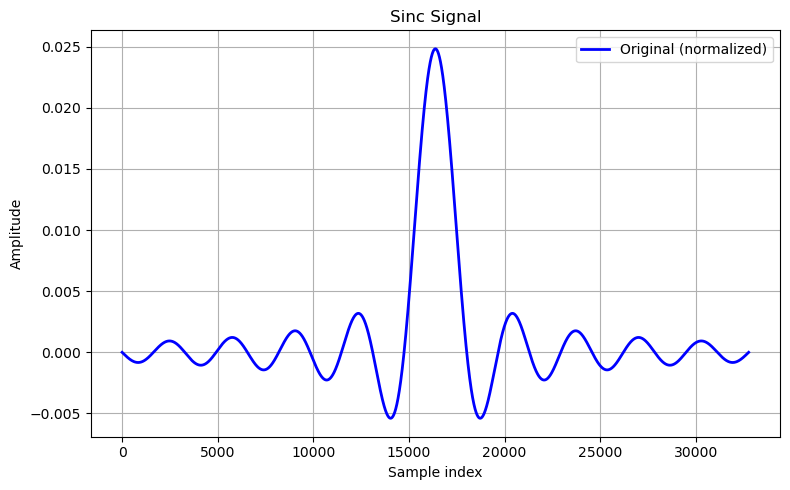

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, label="Original (normalized)", lw=2, color="blue")

plt.title(f"Sinc Signal")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()

## Phase I: Compression of the Sinc Signal

In [21]:
# Apply 10-level discrete packet Haar wavelet transformation on sinc signal
level = 10
X = haar_packet_transform(x, level)

### Classical Sparsity Analysis

The transform-domain coefficients are analyzed in order to identify sparse representations suitable for quantum state preparation.

In [22]:
results = search_sparse_haar_representations(
    x,
    tolerance=0.04
)

Level=7 | Threshold=1.128e-02 | Nonzero=762 | Sparsity=0.023 | Trace Distance=3.842814e-03 | Fidelity=0.999985
Level=7 | Threshold=2.255e-02 | Nonzero=546 | Sparsity=0.017 | Trace Distance=7.205176e-03 | Fidelity=0.999948
Level=7 | Threshold=5.638e-02 | Nonzero=352 | Sparsity=0.011 | Trace Distance=1.441268e-02 | Fidelity=0.999792
Level=7 | Threshold=1.128e-01 | Nonzero=276 | Sparsity=0.008 | Trace Distance=2.261433e-02 | Fidelity=0.999489
Level=7 | Threshold=2.255e-01 | Nonzero=224 | Sparsity=0.007 | Trace Distance=3.606766e-02 | Fidelity=0.998699
Level=8 | Threshold=1.579e-02 | Nonzero=528 | Sparsity=0.016 | Trace Distance=4.444095e-03 | Fidelity=0.999980
Level=8 | Threshold=3.157e-02 | Nonzero=388 | Sparsity=0.012 | Trace Distance=8.120291e-03 | Fidelity=0.999934
Level=8 | Threshold=7.894e-02 | Nonzero=240 | Sparsity=0.007 | Trace Distance=1.802025e-02 | Fidelity=0.999675
Level=8 | Threshold=1.579e-01 | Nonzero=170 | Sparsity=0.005 | Trace Distance=2.964003e-02 | Fidelity=0.999121
L

### Top-k Sparsification

To obtain a sparse transform-domain representation suitable for sparse quantum state preparation, only the largest \(k=110\) Haar-domain coefficients are retained while the remaining coefficients are discarded.

In [23]:
k = 110
Xr = top_k_threshold(X, k)

### Normalization
The `X_norm` is the output of Phase I.

In [24]:
X_norm = Xr/np.linalg.norm(Xr)

### Classical Signal Reconstruction

In [25]:
x_rec = inverse_haar_packet_transform(X_norm, 10)

### Trace Distance

In [26]:
TD = trace_distance(x_rec, target_f)

### Visualization

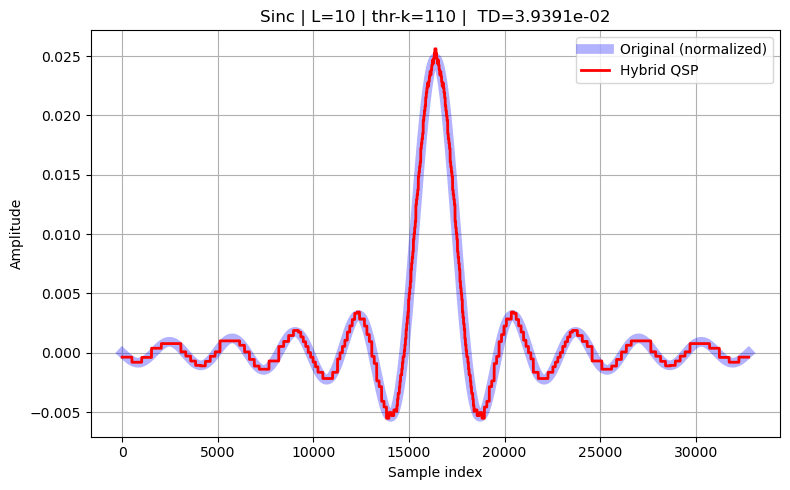

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(x_rec, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();

plt.savefig("../figures/Sinc_signal_preparation.pdf")
plt.show()

## Phase II: Quantum Decompression
The sparse Haar-domain representation is normalized and encoded into a quantum state. The inverse Quantum Packet Haar Wavelet Transform is then applied in order to reconstruct the original signal quantum mechanically.

In [28]:
from qibo import Circuit, gates
from qibo.models.encodings import sparse_encoder
from qibo.ui import plot_circuit

In [29]:
# Sparse transform-domain coefficient vector
vec = X_norm

# Indices of nonzero coefficients
nz = np.flatnonzero(vec)

# Number of qubits required for amplitude encoding
nqubits = int(np.log2(len(vec)))

# Construct sparse basis-state representation
# as (bitstring, amplitude) pairs
y = [
    (format(i, f"0{nqubits}b"), vec[i])
    for i in nz
]

# Prepare sparse quantum state using
# the Farias sparse state preparation method
qc = sparse_encoder(
    y,
    method="farias"
)

# Construct inverse quantum Haar packet
# wavelet transform circuit
iqphwt = build_inverse_qphwt_circuit(
    n=nqubits,
    level=level
)

# Apply inverse quantum transformation
# for signal reconstruction
qc.add(
    iqphwt.on_qubits(*range(nqubits))
)

# Print the decomposed circuit statistics
print(
    qc.decompose().decompose().summary()
)

Circuit depth = 812
Total number of gates = 1343
Number of qubits = 15
Most common gates:
cx: 779
x: 284
ry: 232
h: 48
None


### Statevector of the Quantum SQSP and Quantum Decompression

In [30]:
result = qc()

state = result.state()

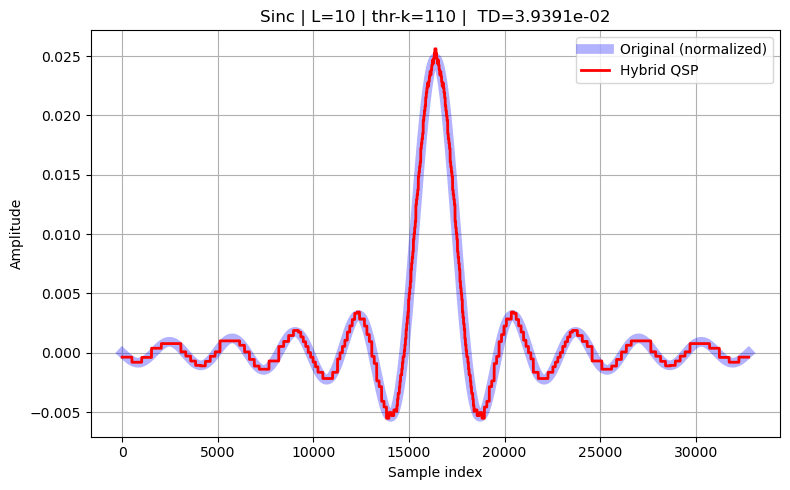

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(target_f, 'blue', lw=7, alpha=0.3, label="Original (normalized)")
plt.plot(state.real, lw=2, color="red", label="Hybrid QSP")
plt.title(f"Sinc | L={level} | thr-k={k} |  TD={TD:.4e}")
plt.xlabel("Sample index");
plt.ylabel("Amplitude")
plt.grid(True);
plt.legend();
plt.tight_layout();
plt.show()